<a href="https://colab.research.google.com/github/shreyadighe30/Hello/blob/main/Copy_of_Practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/car_evaluation.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/EXP 4 Dataset/car_evaluation.csv",
    header=None
)

# Rename columns
df.columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [ ]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Convert categorical values to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
for col in df.columns:
    df[col] = labelencoder.fit_transform(df[col])
df.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [ ]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,1.553241
std,1.118358,1.118358,1.118358,0.816733,0.816733,0.816733,0.875948
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.750000,0.750000,0.750000,0.000000,0.000000,0.000000,1.000000
50%,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,2.000000
75%,2.250000,2.250000,2.250000,2.000000,2.000000,2.000000,2.000000
max,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000


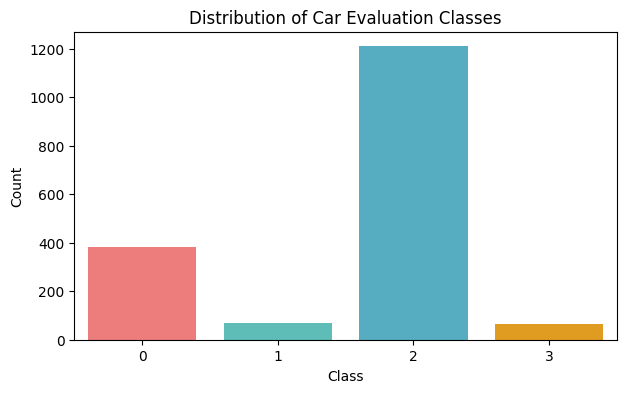

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Define colors for each class
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA600']  # Adjust based on number of classes
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='class', hue='class', palette=colors, legend=False)
plt.title("Distribution of Car Evaluation Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()


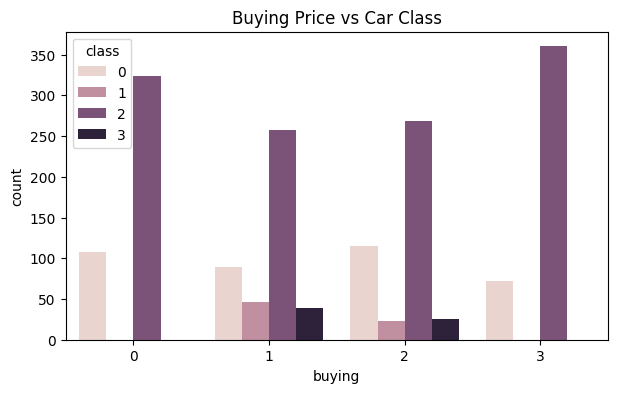

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='buying', hue='class')
plt.title("Buying Price vs Car Class")
plt.show()


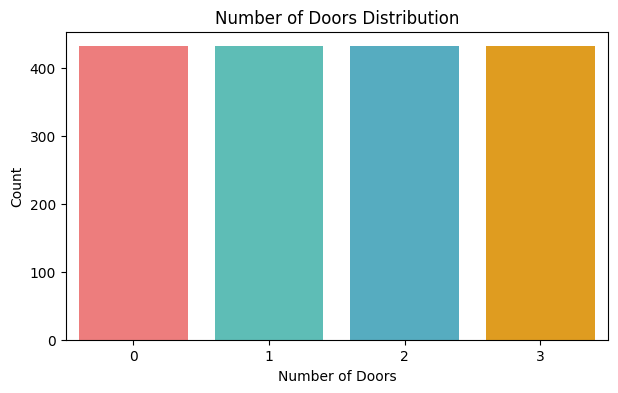

In [ ]:
# Define colors for each door category
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA600', '#9B59B6']

plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x='doors',
    hue='doors',
    palette=colors,
    legend=False
)
plt.title("Number of Doors Distribution")
plt.xlabel("Number of Doors")
plt.ylabel("Count")
plt.show()


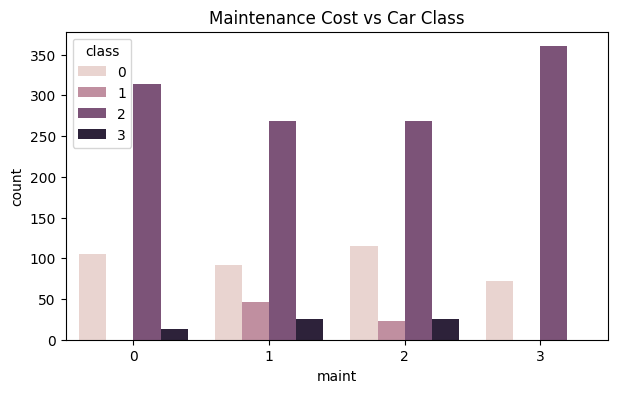

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='maint', hue='class')
plt.title("Maintenance Cost vs Car Class")
plt.show()


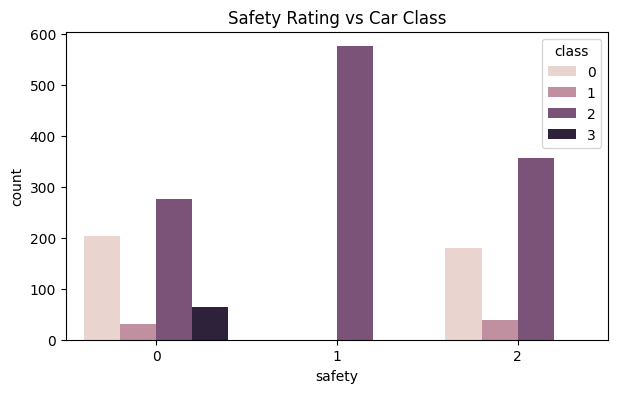

In [ ]:

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='safety', hue='class')
plt.title("Safety Rating vs Car Class")
plt.show()


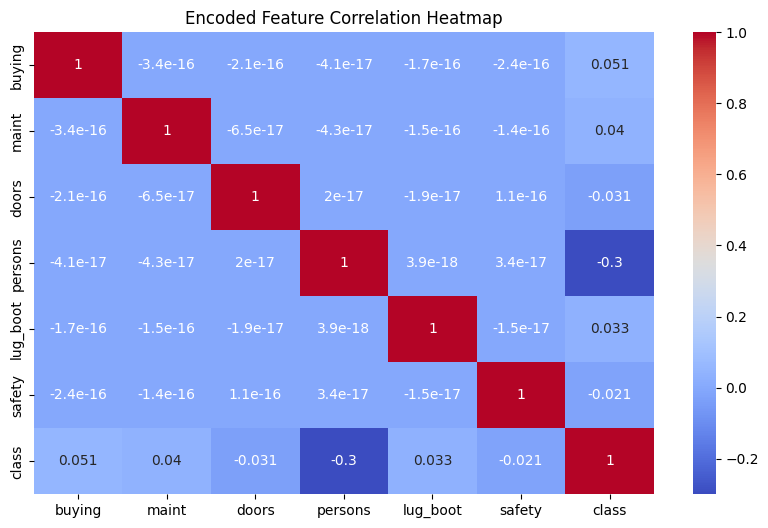

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.apply(LabelEncoder().fit_transform)
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Encoded Feature Correlation Heatmap")
plt.show()


In [ ]:
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)



Training Set Size: (1382, 6)
Testing Set Size: (346, 6)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,     # Number of trees
    criterion='gini',     # Splitting criterion: to decide best fit
    max_depth=None,       # Let it expand fully
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n----- Model Evaluation -----")
print("Accuracy of Random Forest Classifier: {:.2f}%".format(accuracy * 100))



----- Model Evaluation -----
Accuracy of Random Forest Classifier: 98.27%


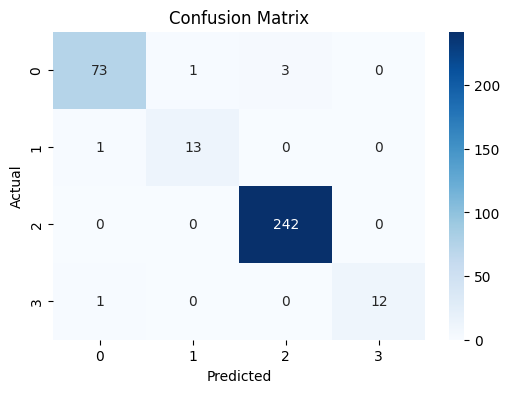

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        77
           1       0.93      0.93      0.93        14
           2       0.99      1.00      0.99       242
           3       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346



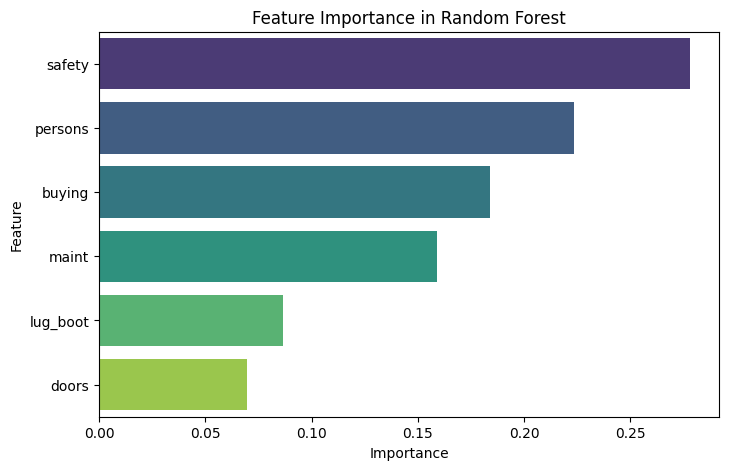

In [ ]:
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Random Forest')
plt.show()
